In [2]:
import pandas as pd
import numpy as np
import os
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import scale
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import \
    train_test_split, StratifiedShuffleSplit, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score


from modules.matrix_processor import MatrixProcessor
import warnings
warnings.filterwarnings('ignore')

In [ ]:
manifest = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/manifest/Cristiano_manifest.csv')
gc_content = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/processing/gc_content_per_region.csv')
if 'length' in gc_content.columns:
    gc_content = gc_content.drop(columns=['length'])
# need to transpose gc_content to have features as columns and regions as rows
sample_ids = manifest['seqrun_id'].apply(lambda x: f'EE{x}').values
metadata_cols = ['sample_name', 'stage', 'disease', 'tissue', 'cancer_true']

print(f"Total samples: {len(sample_ids)}")
print(f"head: {sample_ids[:5]}")


Total samples: 459
head: <StringArray>
['EE87786', 'EE87787', 'EE87788', 'EE87789', 'EE87790']
Length: 5, dtype: str


In [9]:
length_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_length.csv"
pfe_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_pfe.csv"
fsd_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_fsd.csv"
edm_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_edm.csv"
cov_path = "/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/by_feature/matrix_coverage.csv"

## PANCAN model - healthy vs cancer

## Length

Splitting the data into train and test  

In [6]:
df = pd.read_csv(length_path)
print(f"Cancer types: {df['disease'].unique()}")
df_length = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_length['cancer_true'] = df_length['disease'].apply(lambda x: 0 if x == 'Healthy' else 1)
print(df['disease'].value_counts())
print(df_length['disease'].unique())
X_length = df_length.drop(columns=metadata_cols)
y_length = df_length['cancer_true']

# preprocessing:
# standardize and GC correct
matrix_processor = MatrixProcessor(mx = X_length, gc_file=gc_content)
X_length = matrix_processor.standardize()
X = X_length
y = y_length
FEATURE = 'length'



Cancer types: <StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str
disease
Healthy              246
Breast cancer         53
Pancreatic cancer     35
Ovarian cancer        28
Colorectal cancer     27
Bile duct cancer      25
Gastric cancer        24
Lung cancer           20
Duodenal cancer        1
Name: count, dtype: int64
<StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str


In [ ]:
# 10x10fold cross validation to get mean and ci of AUC
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
auc_list = []

for train_idx, test_idx in rskf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = svm.SVC(kernel='linear', probability=True)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_list.append(auc)

avg_auc = np.mean(auc_list)
se = np.std(auc_list) / np.sqrt(len(auc_list))
ci_lower = avg_auc - 2 * se
ci_upper = avg_auc + 2 * se

print(f"{FEATURE.upper()} AUC: {avg_auc:.4f} (95% CI: {ci_lower:.4f}, {ci_upper:.4f})")
print(f"Zhou: 0.8741 (95% CI: 0.8634, 0.8848)")

LENGTH AUC: 0.9109 (95% CI: 0.9017, 0.9201)
Zhou: 0.8741 (95% CI: 0.8634, 0.8848)


### **Meta Matrix Column - LENGTH**

In [15]:
# stratified kfold once, to get one probability per sample
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
probabilities = np.full(len(y), np.nan)

for train_i, test_i in skf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train = y.iloc[train_i]

    model = svm.SVC(probability=True)
    model.fit(X_train, y_train)
    probabilities[test_i] = model.predict_proba(X_test)[:, 1]

In [17]:
# save to csv
length_svm = pd.DataFrame({
    'sample_id': X.index,
    'disease': df_length['disease'],
    'probability': probabilities
})
length_svm.to_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/svm_by_feature/svm_length_probs.csv', index=False)

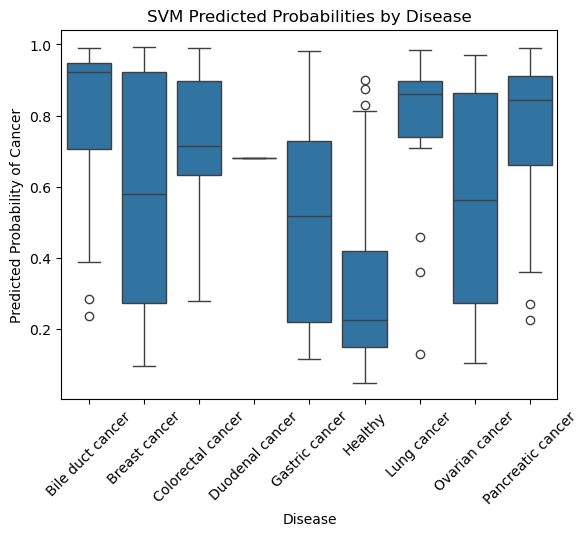

In [18]:
# plot probabilities by disease
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='disease', y='probability', data=length_svm)
plt.xticks(rotation=45)
plt.title('SVM Predicted Probabilities by Disease')
plt.xlabel('Disease')
plt.ylabel('Predicted Probability of Cancer')
plt.show()

## EDM

Splitting the data into train and test  

In [19]:
df = pd.read_csv(edm_path)
print(f"Cancer types: {df['disease'].unique()}")
df_edm = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_edm['cancer_true'] = df_edm['disease'].apply(lambda x: 0 if x == 'Healthy' else 1)
print(df['disease'].value_counts())
print(df_edm['disease'].unique())
X_edm = df_edm.drop(columns=metadata_cols)
y_edm = df_edm['cancer_true']

# preprocessing:
# standardize and GC correct
matrix_processor = MatrixProcessor(mx = X_edm, gc_file=gc_content)
X_edm = matrix_processor.standardize()
X = X_edm
y = y_edm
FEATURE = 'edm'



Cancer types: <StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str
disease
Healthy              246
Breast cancer         53
Pancreatic cancer     35
Ovarian cancer        28
Colorectal cancer     27
Bile duct cancer      25
Gastric cancer        24
Lung cancer           20
Duodenal cancer        1
Name: count, dtype: int64
<StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str


In [ ]:
# 10x10fold cross validation to get mean and ci of AUC
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
auc_list = []

for train_i, test_i in rskf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = y.iloc[train_i], y.iloc[test_i]

    model = svm.SVC(kernel='linear', probability=True)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_list.append(auc)

avg_auc = np.mean(auc_list)
se = np.std(auc_list) / np.sqrt(len(auc_list))
ci_lower = avg_auc - 2 * se
ci_upper = avg_auc + 2 * se

print(f"{FEATURE.upper()} AUC: {avg_auc:.4f} (95% CI: {ci_lower:.4f}, {ci_upper:.4f})")
print(f"Zhou: 0.8741 (95% CI: 0.8634, 0.8848)")

EDM AUC: 0.9673 (95% CI: 0.9624, 0.9721)
Zhou: 0.8741 (95% CI: 0.8634, 0.8848)


### **Meta Matrix Column - EDM**

In [21]:

# stratified kfold once, to get one probability per sample
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
probabilities = np.full(len(y), np.nan)

for train_i, test_i in skf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train = y.iloc[train_i]

    model = svm.SVC(probability=True)
    model.fit(X_train, y_train)
    probabilities[test_i] = model.predict_proba(X_test)[:, 1]

In [22]:
# save to csv
edm_svm = pd.DataFrame({
    'sample_id': X.index,
    'disease': df_edm['disease'],
    'probability': probabilities
})
edm_svm.to_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/svm_by_feature/svm_edm_probs.csv', index=False)

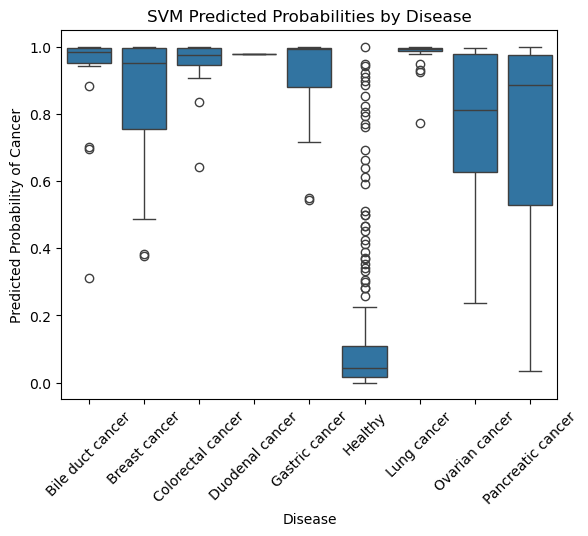

In [23]:
# plot probabilities by disease
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='disease', y='probability', data=edm_svm)
plt.xticks(rotation=45)
plt.title('SVM Predicted Probabilities by Disease')
plt.xlabel('Disease')
plt.ylabel('Predicted Probability of Cancer')
plt.show()

## FSD

Splitting the data into train and test  

In [4]:
df = pd.read_csv(fsd_path)
print(f"Cancer types: {df['disease'].unique()}")
df_fsd = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_fsd['cancer_true'] = df_fsd['disease'].apply(lambda x: 0 if x == 'Healthy' else 1)
print(df['disease'].value_counts())
print(df_fsd['disease'].unique())
X_fsd = df_fsd.drop(columns=metadata_cols)
y_fsd = df_fsd['cancer_true']

# preprocessing:
# standardize and GC correct
matrix_processor = MatrixProcessor(mx = X_fsd, gc_file=gc_content)
X_fsd = matrix_processor.standardize()
X_fsd.fillna(0, inplace=True)
X = X_fsd
y = y_fsd
FEATURE = 'fsd'



Cancer types: <StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str
disease
Healthy              246
Breast cancer         53
Pancreatic cancer     35
Ovarian cancer        28
Colorectal cancer     27
Bile duct cancer      25
Gastric cancer        24
Lung cancer           20
Duodenal cancer        1
Name: count, dtype: int64
<StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str


In [6]:
# 10x10fold cross validation to get mean and ci of AUC
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
auc_list = []

for train_i, test_i in rskf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = y.iloc[train_i], y.iloc[test_i]

    model = svm.SVC(kernel='linear', probability=True)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_list.append(auc)

avg_auc = np.mean(auc_list)
se = np.std(auc_list) / np.sqrt(len(auc_list))
ci_lower = avg_auc - 2 * se
ci_upper = avg_auc + 2 * se

print(f"{FEATURE.upper()} AUC: {avg_auc:.4f} (95% CI: {ci_lower:.4f}, {ci_upper:.4f})")


FSD AUC: 0.9075 (95% CI: 0.8982, 0.9169)


### **Meta Matrix Column - FSD**

In [5]:

# stratified kfold once, to get one probability per sample
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
probabilities = np.full(len(y), np.nan)

for train_i, test_i in skf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train = y.iloc[train_i]

    model = svm.SVC(probability=True, max_iter=1000)
    model.fit(X_train, y_train)
    probabilities[test_i] = model.predict_proba(X_test)[:, 1]

In [7]:
# save to csv
fsd_svm = pd.DataFrame({
    'sample_id': X.index,
    'disease': df_fsd['disease'],
    'probability': probabilities
})
fsd_svm.to_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/svm_by_feature/svm_fsd_probs.csv', index=False)

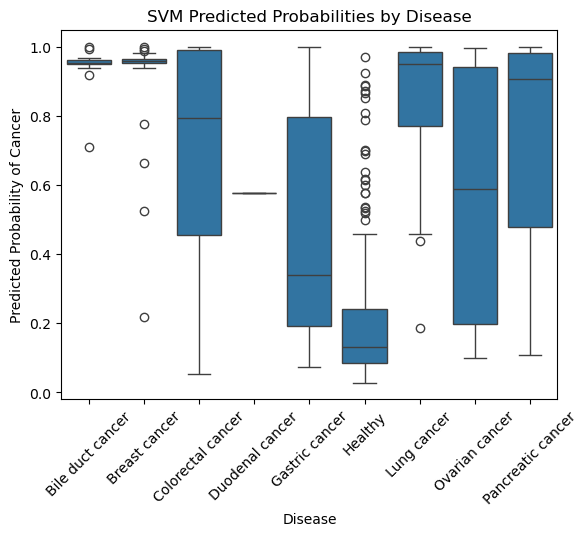

In [8]:
# plot probabilities by disease
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='disease', y='probability', data=fsd_svm)
plt.xticks(rotation=45)
plt.title('SVM Predicted Probabilities by Disease')
plt.xlabel('Disease')
plt.ylabel('Predicted Probability of Cancer')
plt.show()

## Coverage

Splitting the data into train and test  

In [12]:
df = pd.read_csv(cov_path)
print(f"Cancer types: {df['disease'].unique()}")
df_cov = df.drop(columns=['seqrun_id']).set_index('sample_id')
df_cov['cancer_true'] = df_cov['disease'].apply(lambda x: 0 if x == 'Healthy' else 1)
print(df['disease'].value_counts())
print(df_cov['disease'].unique())
X_cov = df_cov.drop(columns=metadata_cols)
y_cov = df_cov['cancer_true']

# preprocessing:
# standardize and GC correct
matrix_processor = MatrixProcessor(mx = X_cov, gc_file=gc_content)
X_cov = matrix_processor.standardize()
X_cov = matrix_processor.GC_correction()
# X_cov.fillna(0, inplace=True)
X = X_cov
y = y_cov
FEATURE = 'coverage'



Cancer types: <StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str
disease
Healthy              246
Breast cancer         53
Pancreatic cancer     35
Ovarian cancer        28
Colorectal cancer     27
Bile duct cancer      25
Gastric cancer        24
Lung cancer           20
Duodenal cancer        1
Name: count, dtype: int64
<StringArray>
[ 'Bile duct cancer',     'Breast cancer', 'Colorectal cancer',
   'Duodenal cancer',    'Gastric cancer',           'Healthy',
       'Lung cancer',    'Ovarian cancer', 'Pancreatic cancer']
Length: 9, dtype: str


KeyError: 'coverage_region_0'

In [16]:
import numpy as np

# Align gc columns to feature columns
region_ids = [int(c.rsplit('_', 1)[-1]) for c in X_cov.columns]
gc_np = gc_content[region_ids].values  # 459 × 561k
X_np = X_cov.values                    # 459 × 561k

# Center GC values per feature
gc_centered = gc_np - gc_np.mean(axis=0)  # 459 × 561k

# Vectorized OLS: beta_j = (gc_j · X_j) / (gc_j · gc_j)
numerator   = (gc_centered * X_np).sum(axis=0)      # 561k
denominator = (gc_centered ** 2).sum(axis=0)         # 561k
beta        = np.divide(numerator, denominator,
                        out=np.zeros_like(numerator),
                        where=denominator != 0)       # avoid div/0

fitted   = gc_centered * beta                        # 459 × 561k
X_np_corrected = X_np - fitted

X_cov = pd.DataFrame(X_np_corrected, index=X_cov.index, columns=X_cov.columns)
X = X_cov
print("GC correction done")
y = y_cov
FEATURE = 'coverage'

GC correction done


In [ ]:
# 10x10fold cross validation to get mean and ci of AUC
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=1)
auc_list = []

for train_i, test_i in rskf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train, y_test = y.iloc[train_i], y.iloc[test_i]

    model = svm.SVC(kernel='linear', probability=True)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_list.append(auc)

avg_auc = np.mean(auc_list)
se = np.std(auc_list) / np.sqrt(len(auc_list))
ci_lower = avg_auc - 2 * se
ci_upper = avg_auc + 2 * se

print(f"{FEATURE.upper()} AUC: {avg_auc:.4f} (95% CI: {ci_lower:.4f}, {ci_upper:.4f})")


FSD AUC: 0.9075 (95% CI: 0.8982, 0.9169)


### **Meta Matrix Column - Coverage**

In [ ]:

# stratified kfold once, to get one probability per sample
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
probabilities = np.full(len(y), np.nan)

for train_i, test_i in skf.split(X, y):
    X_train, X_test = X.iloc[train_i], X.iloc[test_i]
    y_train = y.iloc[train_i]

    model = svm.SVC(probability=True, max_iter=1000)
    model.fit(X_train, y_train)
    probabilities[test_i] = model.predict_proba(X_test)[:, 1]

In [ ]:
# save to csv
cov_svm = pd.DataFrame({
    'sample_id': X.index,
    'disease': df_cov['disease'],
    'probability': probabilities
})
cov_svm.to_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/matrix/svm_by_feature/svm_cov_probs.csv', index=False)

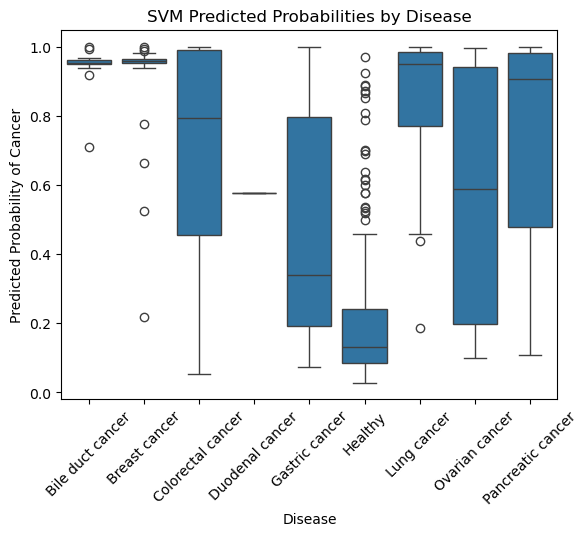

In [ ]:
# plot probabilities by disease
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='disease', y='probability', data=cov_svm)
plt.xticks(rotation=45)
plt.title('SVM Predicted Probabilities by Disease')
plt.xlabel('Disease')
plt.ylabel('Predicted Probability of Cancer')
plt.show()